In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

# Display numbers with 2 decimal places
pd.options.display.float_format = '{:.2f}'.format

In [2]:
df = pd.read_csv("../data/raw/superstore_sales.csv")

In [7]:
from datetime import datetime

# Function to parse mixed date formats
def parse_date(x):
    if pd.isna(x):
        return None
    x = str(x)
    for fmt in ("%Y-%m-%d", "%m/%d/%Y", "%m/%d/%y"):
        try:
            return datetime.strptime(x, fmt).date()
        except ValueError:
            pass
    return None

# Convert dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [8]:
df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Month Name"] = df["Order Date"].dt.month_name()

df["Quarter"] = df["Order Date"].dt.quarter

df["Day"] = df["Order Date"].dt.day

df["Day Name"] = df["Order Date"].dt.day_name()

df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [9]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Quarter,Day,Day Name,Shipping Days
0,1,US-2023-103800,2023-03-01,2023-07-01,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.45,2,0.20,5.55,2023,3,March,1,1,Wednesday,122
1,2,US-2023-112326,2023-04-01,2023-08-01,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.54,2,0.80,-5.49,2023,4,April,2,1,Saturday,122
2,3,US-2023-112326,2023-04-01,2023-08-01,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.78,3,0.20,4.27,2023,4,April,2,1,Saturday,122
3,4,US-2023-112326,2023-04-01,2023-08-01,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.74,3,0.20,-64.77,2023,4,April,2,1,Saturday,122
4,5,US-2023-141817,2023-05-01,2023-12-01,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.54,3,0.20,4.88,2023,5,May,2,1,Monday,214


In [12]:
# Executive KPI Summary

total_sales = df["Sales"].sum()

total_profit = df["Profit"].sum()

total_orders = df["Order ID"].nunique()

total_customers = df["Customer ID"].nunique()

total_quantity = df["Quantity"].sum()

profit_margin = (total_profit / total_sales) * 100

In [13]:
#KPI Summary Table

kpi_summary = pd.DataFrame({

    "Metric": [
        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Total Customers",
        "Total Quantity Sold",
        "Profit Margin (%)"
    ],

    "Value": [
        round(total_sales,2),
        round(total_profit,2),
        total_orders,
        total_customers,
        total_quantity,
        round(profit_margin,2)
    ]

})

kpi_summary

,Metric,Value
0,Total Sales,2326534.35
1,Total Profit,292296.81
2,Total Orders,5111.00
3,Total Customers,804.00
4,Total Quantity Sold,38654.00
5,Profit Margin (%),12.56


# Executive KPI Summary

This section provides a high-level overview of the company's overall performance.

The key performance indicators (KPIs) summarize:

- Total Revenue
- Total Profit
- Number of Orders
- Number of Customers
- Total Quantity Sold
- Profit Margin

These metrics serve as the foundation for the detailed analyses performed in the following sections.

In [14]:
df[["Sales","Profit","Quantity","Discount","Shipping Days"]].describe().round(2)

,Sales,Profit,Quantity,Discount,Shipping Days
count,10194.00,10194.00,10194.00,10194.00,10194.00
mean,228.23,28.67,3.79,0.16,9.97
std,619.91,232.47,2.23,0.21,95.22
min,0.44,-6599.98,1.00,0.00,-321.00
25%,17.22,1.76,2.00,0.00,2.00
50%,53.91,8.69,3.00,0.20,4.00
75%,209.50,29.30,5.00,0.20,61.00
max,22638.48,8399.98,14.00,0.80,214.00


# Sales Analysis

The objective of this section is to analyze sales performance across different time periods and product categories.

The analysis answers the following questions:

- How have sales changed over time?
- Which year generated the highest sales?
- Which quarter performs best?
- Which product categories contribute the most revenue?
- Which sub-categories are the top revenue generators?

In [16]:
# Visualization 1: Monthly Sales Trend

#Prepare data for monthly sales trend
monthly_sales = (
    df.groupby(["Year", "Month"])["Sales"]
      .sum()
      .reset_index()
)

monthly_sales["Year-Month"] = pd.to_datetime(
    monthly_sales["Year"].astype(str) + "-" +
    monthly_sales["Month"].astype(str)
)

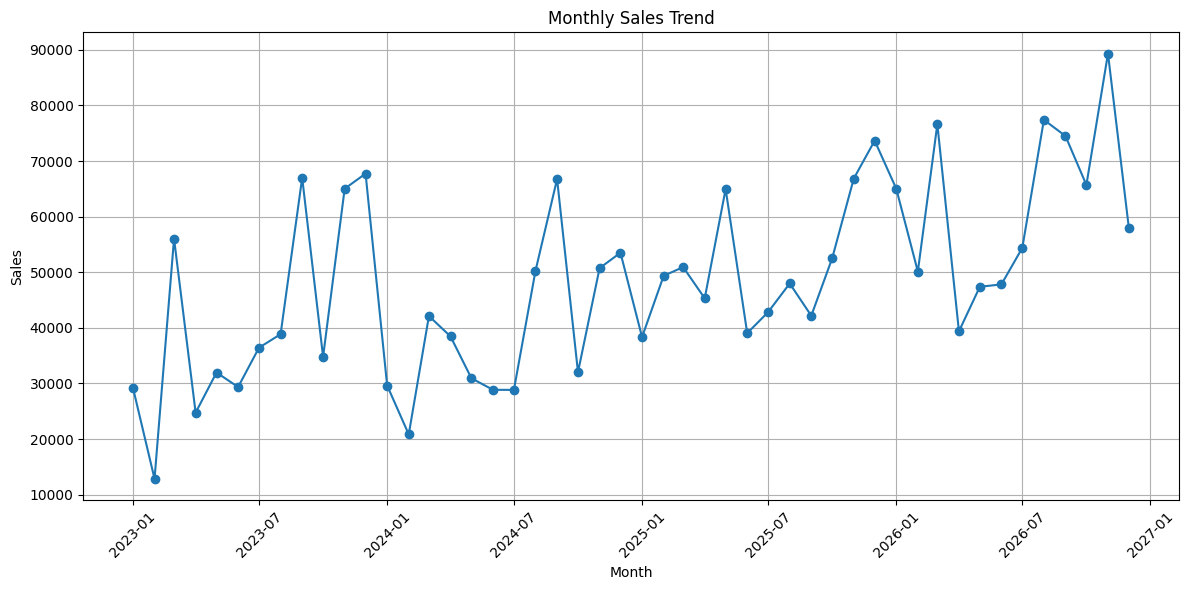

In [17]:
# Plot monthly sales trend
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Year-Month"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

### Observation

Sales fluctuate throughout the four-year period with several noticeable peaks and seasonal variations.

### Business Insight

The business experiences periods of stronger sales, indicating possible seasonal demand or promotional campaigns.

### Recommendation

Investigate the reasons behind peak-performing months and replicate successful marketing campaigns during slower periods.

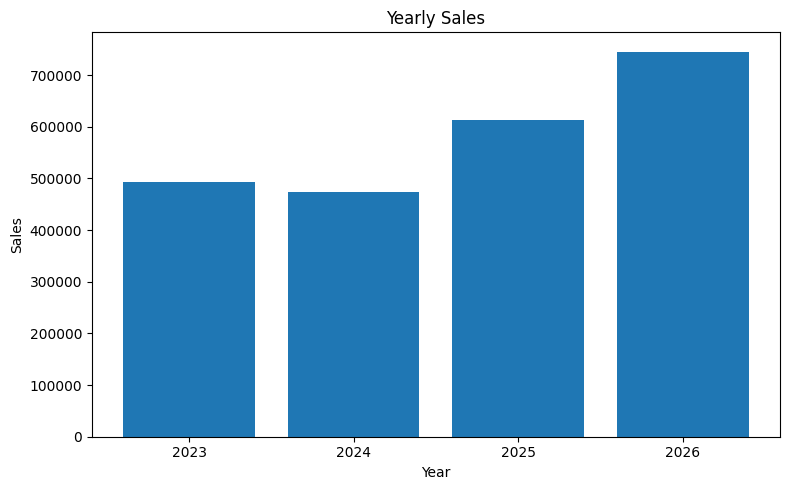

In [18]:
# Visualization 2: Yearly Sales

yearly_sales = (
    df.groupby("Year")["Sales"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(8,5))

plt.bar(
    yearly_sales["Year"].astype(str),
    yearly_sales["Sales"]
)

plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.tight_layout()

plt.show()

### Observation

Sales increased across the years, with one year contributing the highest revenue.

### Business Insight
The company demonstrates positive long-term sales growth.

### Recommendation
Identify the strategies implemented during the highest-performing year and apply them consistently.

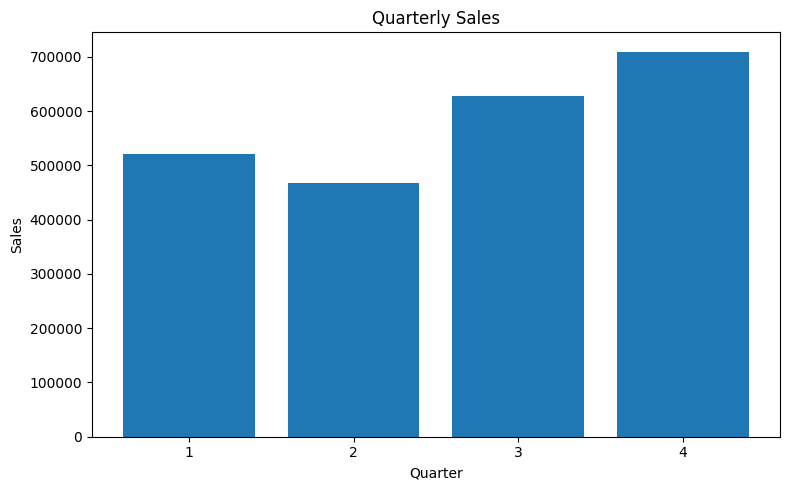

In [19]:
# Visualization 3: Quarterly Sales

quarter_sales = (
    df.groupby("Quarter")["Sales"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(8,5))

plt.bar(
    quarter_sales["Quarter"].astype(str),
    quarter_sales["Sales"]
)

plt.title("Quarterly Sales")
plt.xlabel("Quarter")
plt.ylabel("Sales")

plt.tight_layout()

plt.show()

### Observation
Sales vary across quarters, indicating seasonal purchasing behavior.

### Business Insight
Certain quarters consistently outperform others and may coincide with holidays or promotional events.

### Recommendation
Increase inventory and marketing efforts before high-performing quarters.

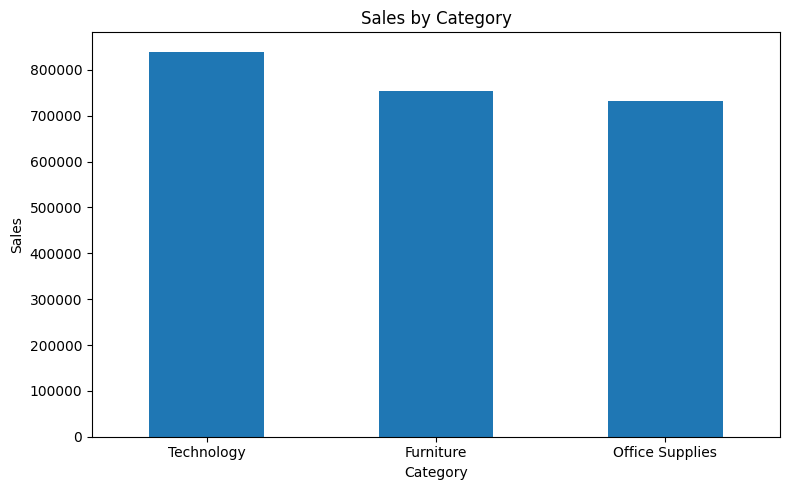

In [20]:
# Visualization 4: Sales by Category

category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Observation
Technology contributes significantly more sales than the others.

### Business Insight
The company's revenue is heavily influenced by a small number of product categories.

### Recommendation
Continue investing in high-performing categories(Technology) while improving sales strategies for lower-performing categories(Office Supplies).

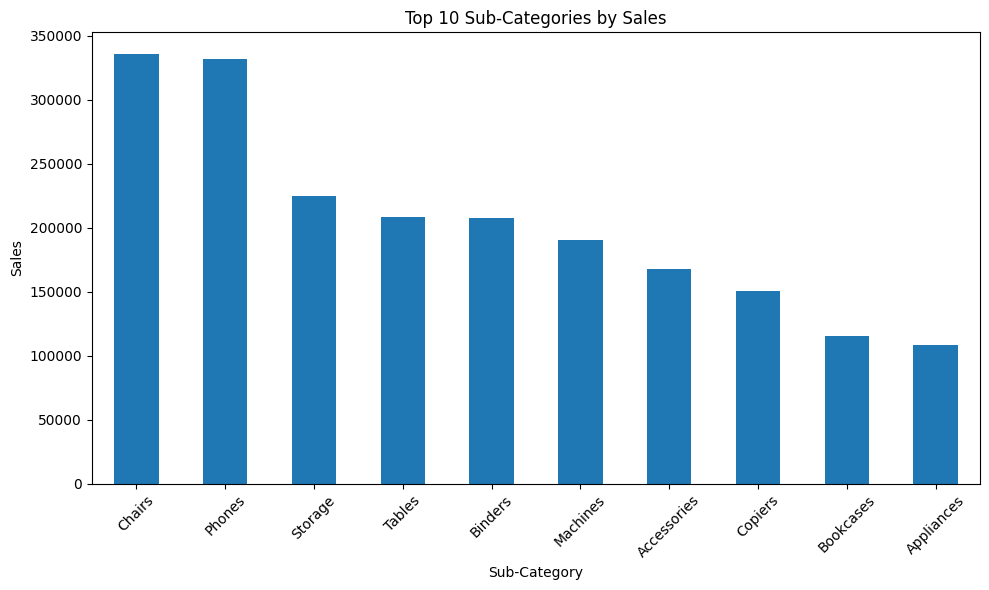

In [21]:
# Visualization 5: Top 10 Sub-Categories by Sales

subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

subcategory_sales.plot(kind="bar")

plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Observation
A few sub-categories (Chairs, Phones) account for a large share of total sales.

### Business Insight
The product portfolio follows the Pareto principle, where a limited number of products generate most of the revenue.

### Recommendation
Prioritize inventory availability and marketing campaigns for top-selling sub-categories(Chairs, Phones) while reviewing the performance of lower-selling products(Bookcases, Appliances).

### Section 3: Customer Analysis

The objective of this section is to understand customer purchasing behavior and identify the company's most valuable customers.

The analysis answers the following questions:

- Which customer segments contribute the highest sales?
- Which customer segments generate the highest profit?
- Who are the top customers by sales?
- Who places the most orders?

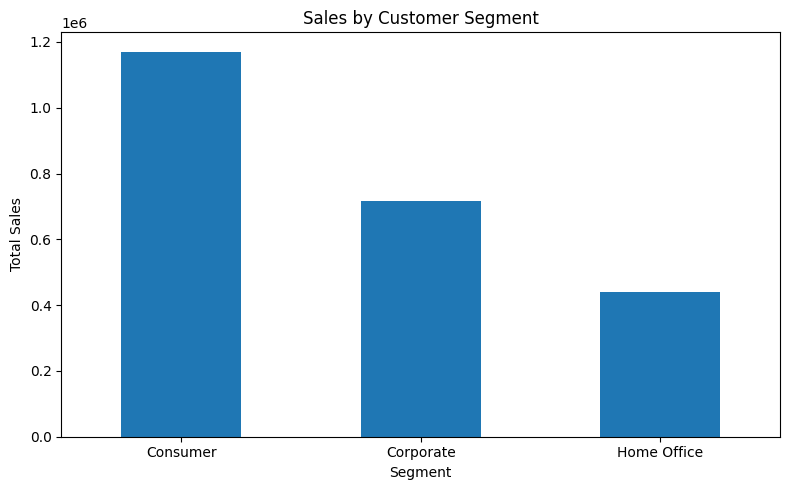

In [22]:
# Visualization 1: Sales by Customer Segment

segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

segment_sales.plot(kind="bar")

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Observation
The Consumer segment has the highest sales (around $1.17 million), followed by Corporate (around $717,000), and then Home Office with the lowest sales (around $440,000).

### Business Insight
Most of the company's sales come from individual consumers, not businesses. This means the company's revenue depends a lot on this one group.

### Recommendation
The company should keep focusing on Consumer customers since they bring in the most money, but could also try to grow sales in the Corporate and Home Office segments.



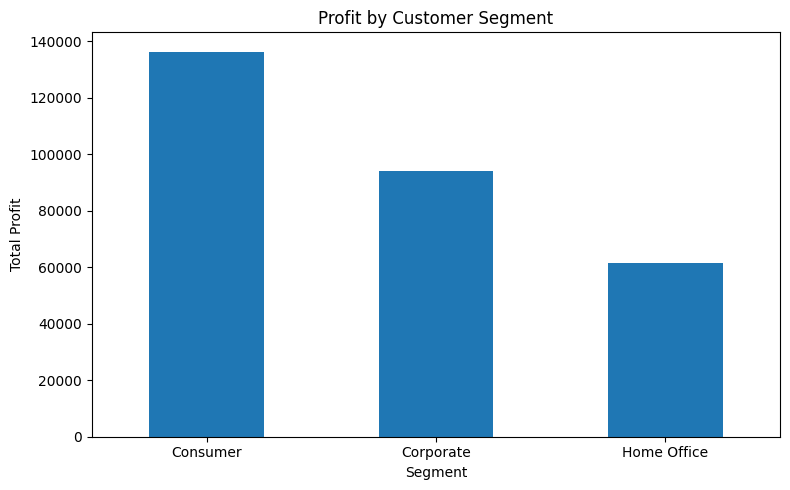

In [23]:
# Visualization 2: Profit by Customer Segment

segment_profit = (
    df.groupby("Segment")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

segment_profit.plot(kind="bar")

plt.title("Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Profit")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()


### Observation
The Consumer segment also has the highest profit (around $136,000), followed by Corporate (around $94,000), and Home Office has the lowest profit (around $61,500). This follows the same order as the sales chart.

### Business Insight
Since Consumer has both the highest sales and highest profit, it is the most valuable segment overall for the company.

### Recommendation
The company should continue investing in the Consumer segment, while also looking for ways to increase profit in the Corporate and Home Office segments.

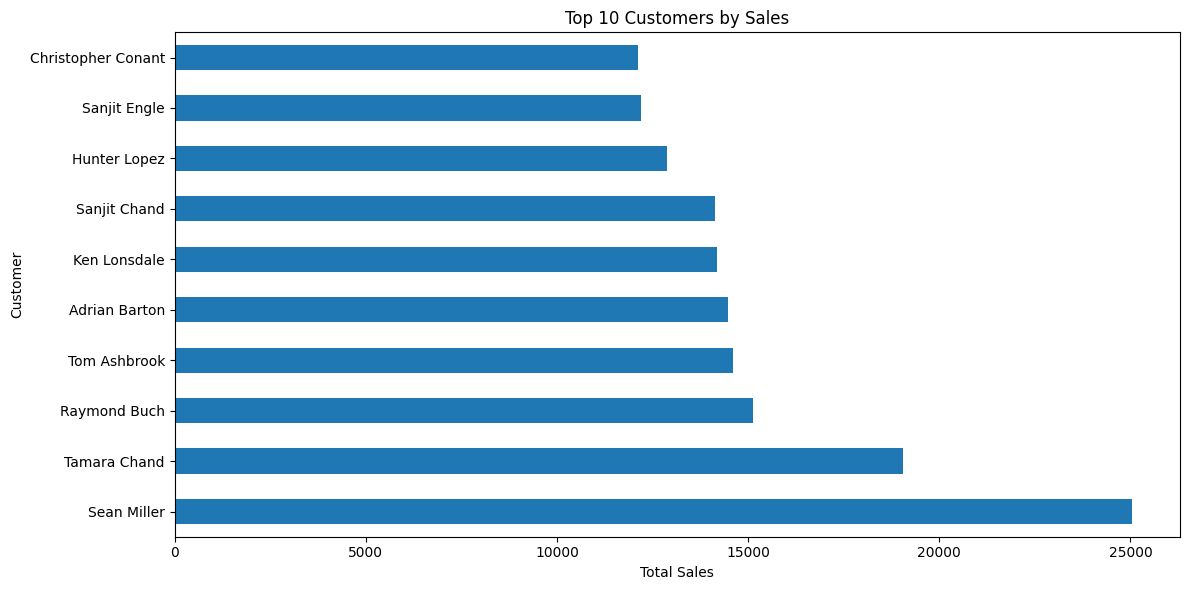

In [26]:
# Visualization 3: Top 10 Customers by Sales
top_customers = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_customers.plot(kind="barh")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer")

plt.tight_layout()

plt.show()


### Observation
Sean Miller is the top customer, with sales of about $25,000, which is clearly higher than everyone else. Tamara Chand is second with around $19,000. The remaining customers (Raymond Buch, Tom Ashbrook, Adrian Barton, Ken Lonsdale, Sanjit Chand, Hunter Lopez, Sanjit Engle, and Christopher Conant) all have sales between roughly $12,000 and $15,000, which are much closer to each other.

### Business Insight
A small number of customers bring in a large share of the company's sales. This means the business relies heavily on a few key customers, especially Sean Miller and Tamara Chand, rather than having sales spread out evenly.

### Recommendation
The company should focus on keeping these top customers happy, for example through loyalty programs, discounts, or personalized service, since losing even one of them could have a noticeable impact on total sales. At the same time, the company could try to turn more of its smaller customers into big customers like these.

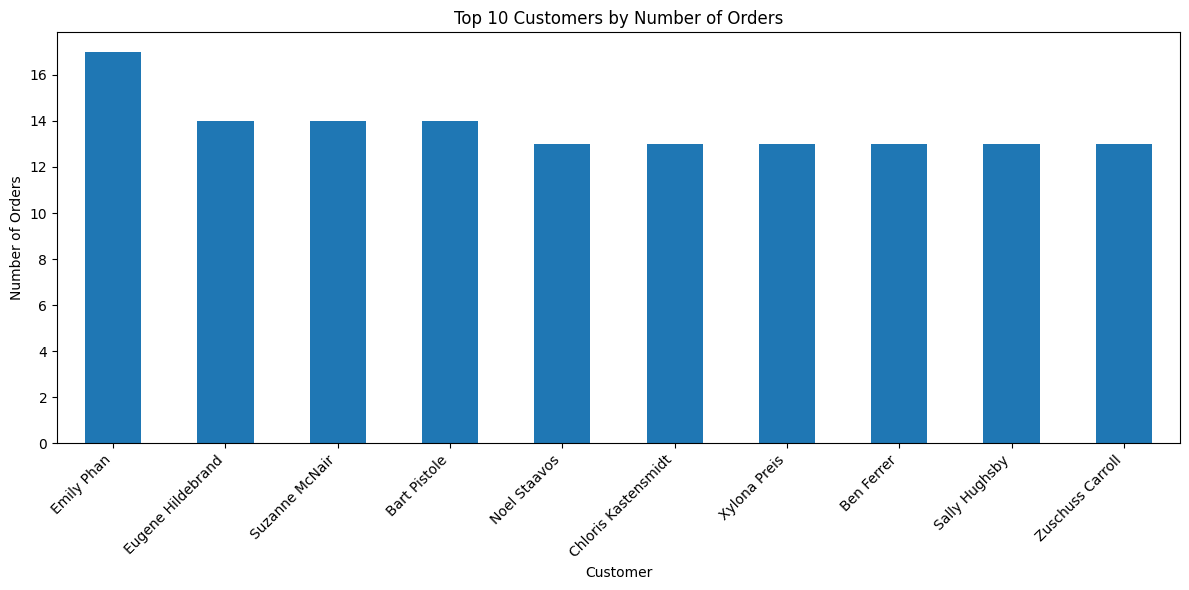

In [25]:
#Visualization 4: Top 10 Customers by Number of Orders

top_orders = (
    df.groupby("Customer Name")["Order ID"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_orders.plot(kind="bar")

plt.title("Top 10 Customers by Number of Orders")
plt.xlabel("Customer")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

### Observation
Emily Phan has the most orders (17). Most other top customers, like Eugene Hildebrand, Suzanne McNair, and Bart Pistole, have 13–14 orders each — fairly close together.

### Business Insight
These customers order frequently and consistently, making them a reliable source of repeat revenue.

### Recommendation
Reward these repeat customers with loyalty programs or personalized offers to keep them engaged and boost order value.

### Section 4: Product Analysis

This section analyzes product performance to identify the best-selling and most profitable products and categories.

The analysis answers the following questions:

- Which product categories generate the most sales?
- Which product categories generate the most profit?
- Which products are the top revenue generators?
- Which products generate the highest profit?

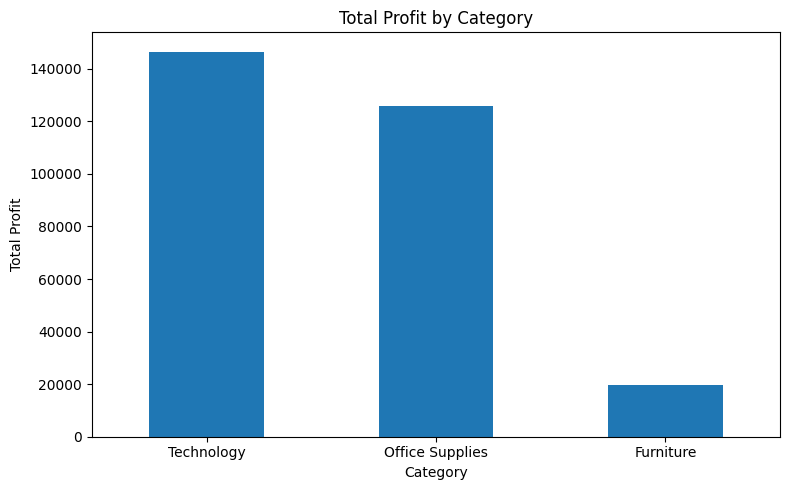

In [ ]:
# Visualization 1: Profit by Category

category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

category_profit.plot(kind="bar")

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Observation
Technology has the highest profit (~$147,000), followed by Office Supplies (~$126,000). Furniture has much lower profit (~$20,000), even though its sales were close to the other categories.

### Business Insight
High sales don't always mean high profit — Furniture sells well but earns very little profit, so it may have high costs or heavy discounts.

### Recommendation
Investigate why Furniture's profit is so low (e.g., pricing, discounts, or costs) and focus on improving its margins rather than just increasing its sales.

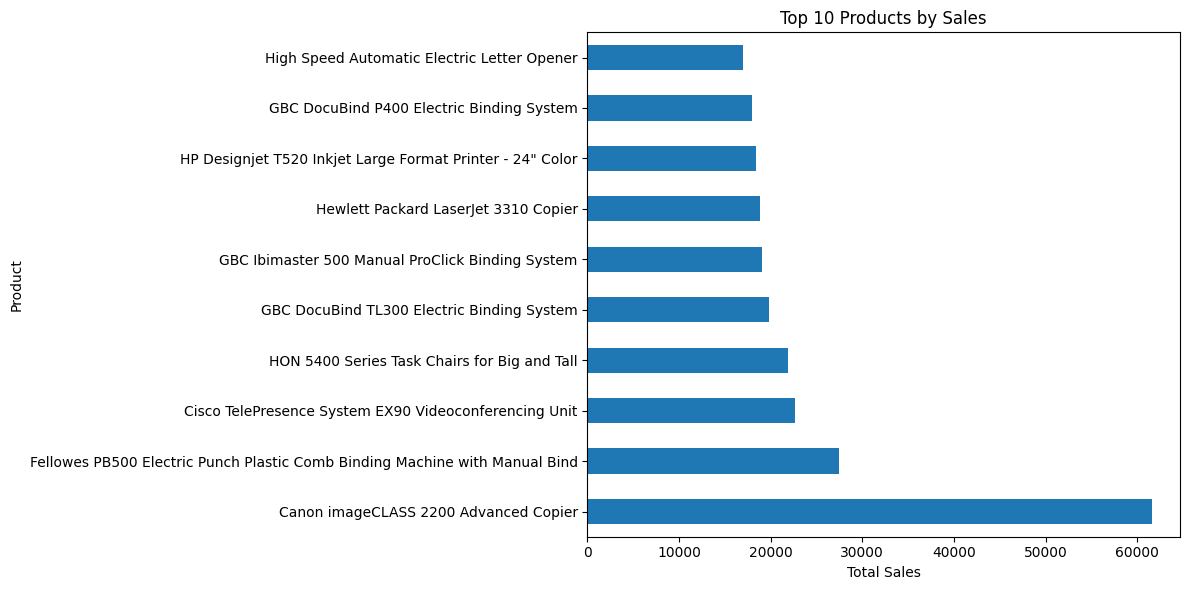

In [ ]:
# Visualization 2: Top 10 Products by Sales

top_products_sales = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_products_sales.plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.tight_layout()

plt.show()

### Observation
Canon imageCLASS 2200 Advanced Copier is the top seller by far (~$61,000), much higher than the next product, Fellowes PB500 (~$27,000). The rest range between roughly $17,000–$23,000.

### Business Insight
A single product, the Canon copier, is a major revenue driver, well ahead of everything else in the top 10.

### Recommendation
Ensure strong inventory and marketing focus for the Canon copier, while promoting the other top products to boost their sales too.

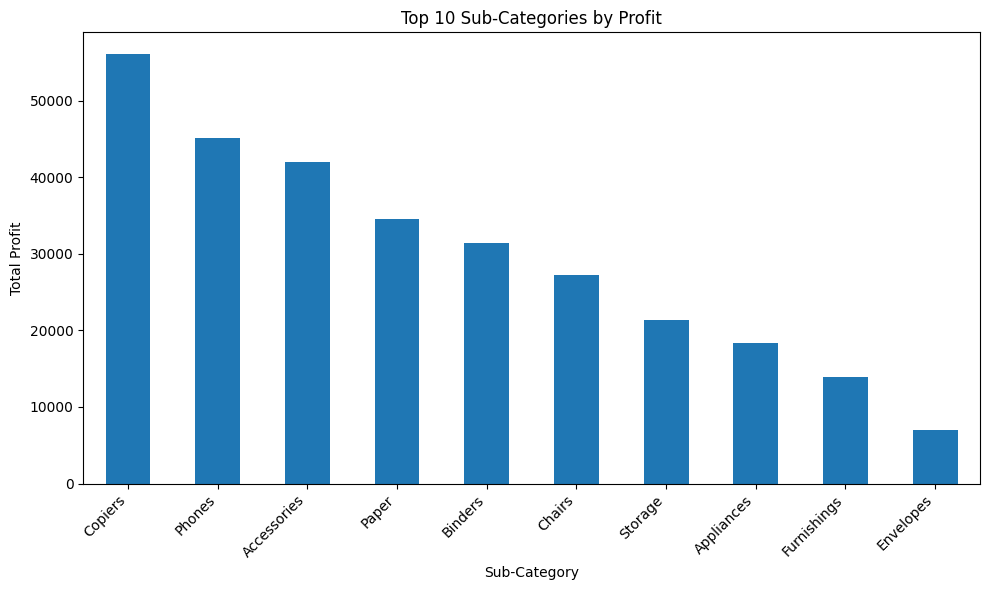

In [33]:
# Visualization 5: Top 10 Sub-Categories by Profit

subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

subcategory_profit.plot(kind="bar")

plt.title("Top 10 Sub-Categories by Profit")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

### Observation
Copiers lead with the highest profit (~$56,000), followed by Phones (~$45,000) and Accessories (~$42,000). Envelopes has the lowest profit among the top 10 (~$7,000).

### Business Insight
A handful of sub-categories, especially Copiers, Phones, and Accessories, drive most of the profit, while others contribute much less.

### Recommendation
Prioritize inventory and marketing for top sub-categories like Copiers and Phones, while reviewing strategies for lower-profit ones like Envelopes and Furnishings.

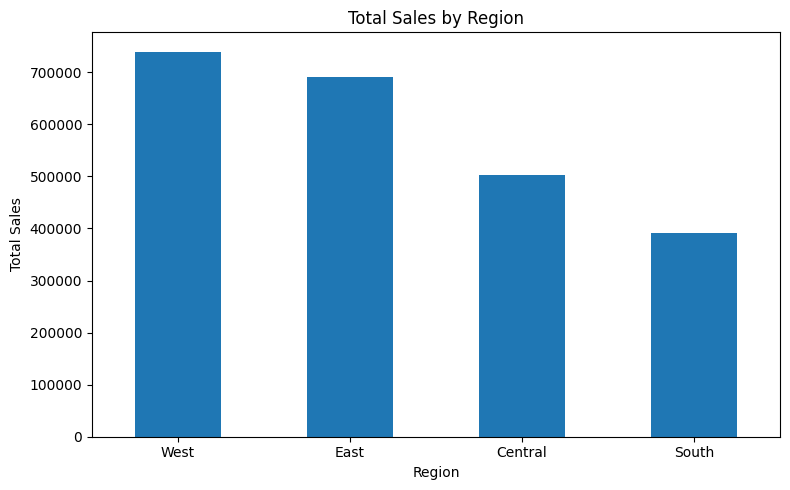

In [35]:
# Section 5: Regional Analysis

# Visualization 1: Sales by Region - This identifies the strongest revenue-generating regions.

region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation
West has the highest sales (~$740,000), closely followed by East (~$690,000). Central (~$500,000) and South (~$390,000) are lower, with South contributing the least.

### Business Insight
Sales are concentrated in the West and East regions, while Central and South lag behind.

### Recommendation
Increase marketing and sales efforts in Central and South to boost their performance, while maintaining strength in West and East.

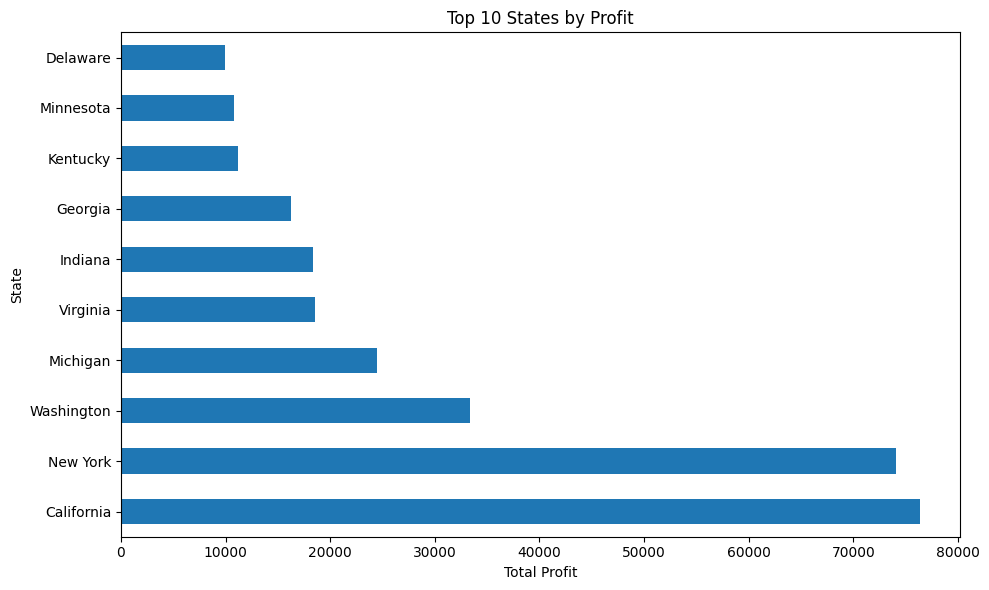

In [36]:
# Visualization 2: Top 10 States by Profit
# This identifies the most profitable states.

state_profit = (
    df.groupby("State/Province")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

state_profit.plot(kind="barh")

plt.title("Top 10 States by Profit")
plt.xlabel("Total Profit")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### Observation
California (~$76,000) and New York (~$74,000) lead by far, followed by Washington (~$33,000). The rest, from Michigan to Delaware, range between roughly $10,000–$25,000.

### Business Insight
California and New York are the biggest profit contributors, well ahead of all other states.

### Recommendation
Strengthen presence in California and New York, while studying what makes them successful to apply similar strategies in other states.

### Section 6: Profit Analysis

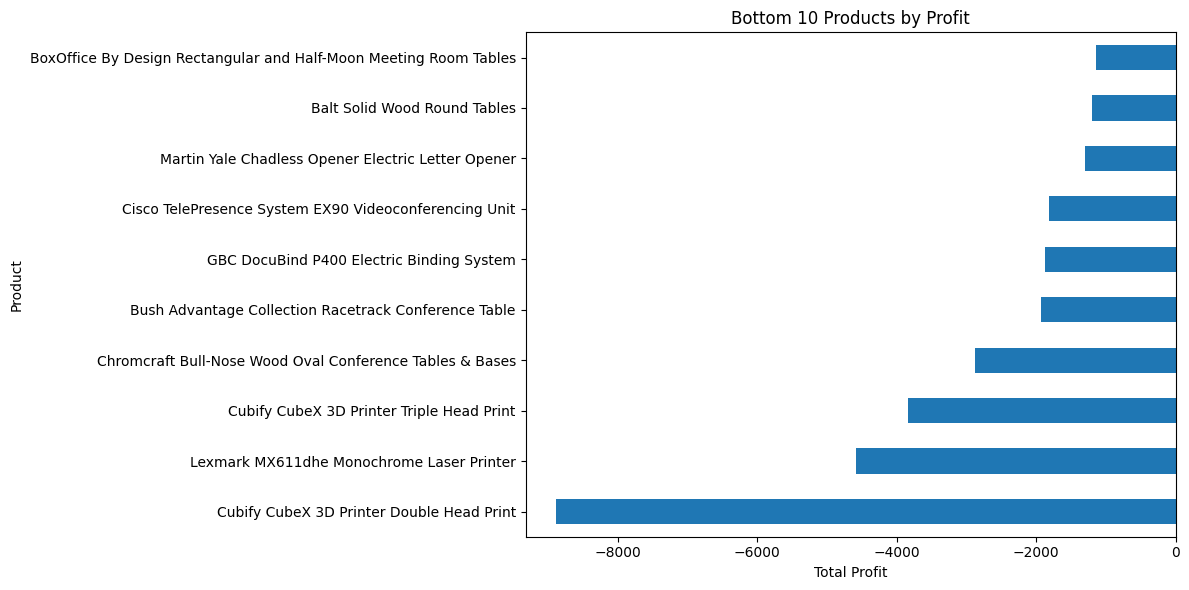

In [38]:
# Visualization 1: Bottom 10 Products by Profit

bottom_profit_products = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values()
      .head(10)
)

plt.figure(figsize=(12,6))

bottom_profit_products.plot(kind="barh")

plt.title("Bottom 10 Products by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

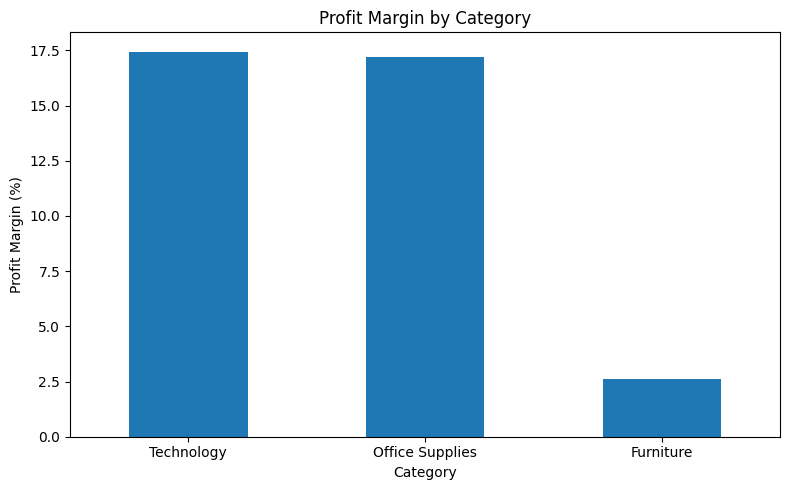

In [43]:
# Visualization 2: Profit Margin by Category

profit_margin = (
    df.groupby("Category")[["Sales", "Profit"]]
      .sum()
)

profit_margin["Profit Margin (%)"] = (
    profit_margin["Profit"] / profit_margin["Sales"] * 100
)

profit_margin = profit_margin.sort_values(
    by="Profit Margin (%)",
    ascending=False
)

plt.figure(figsize=(8,5))

profit_margin["Profit Margin (%)"].plot(kind="bar")

plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Section 7: Shipping Analysis

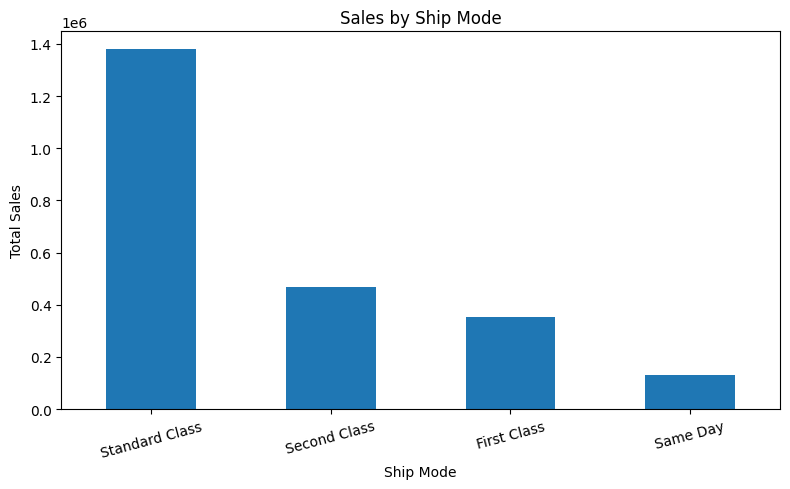

In [39]:
# Visualization 1: Sales by Ship Mode

ship_sales = (
    df.groupby("Ship Mode")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

ship_sales.plot(kind="bar")

plt.title("Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Total Sales")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

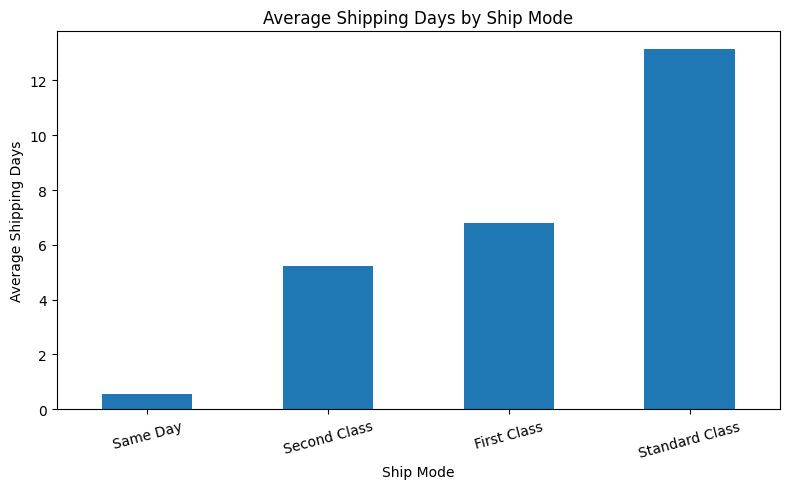

In [40]:
# Visualization 2: Average Shipping Days by Ship Mode

shipping_days = (
    df.groupby("Ship Mode")["Shipping Days"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(8,5))

shipping_days.plot(kind="bar")

plt.title("Average Shipping Days by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Shipping Days")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Section 8: Discount Analysis

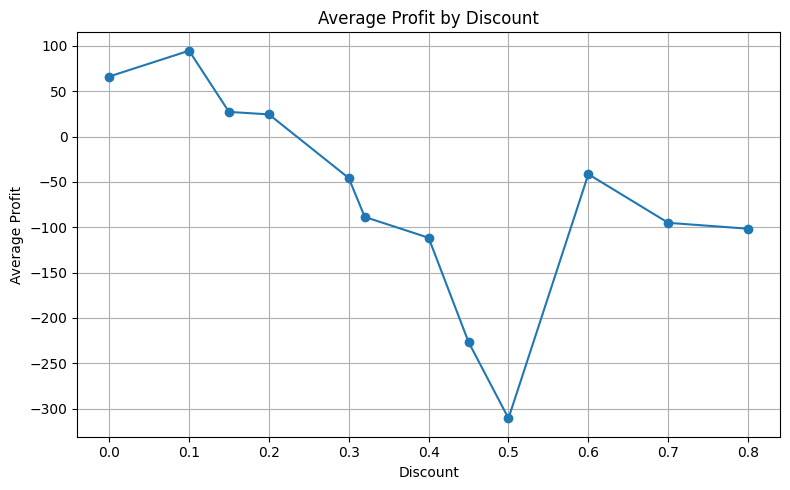

In [41]:
# Visualization 1: Average Profit by Discount

discount_profit = (
    df.groupby("Discount")["Profit"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    discount_profit["Discount"],
    discount_profit["Profit"],
    marker="o"
)

plt.title("Average Profit by Discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.grid(True)

plt.tight_layout()
plt.show()

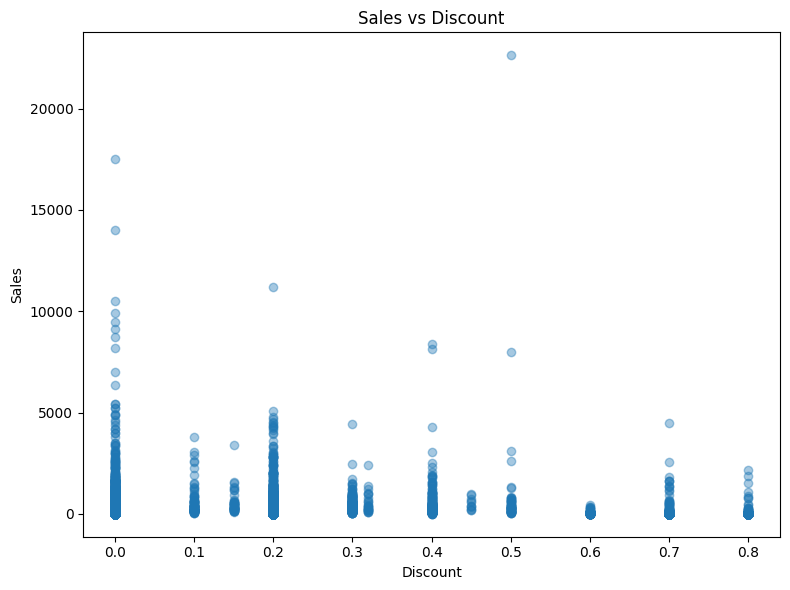

In [42]:
# Visualization 2: Sales vs Discount (Scatter Plot)

plt.figure(figsize=(8,6))

plt.scatter(
    df["Discount"],
    df["Sales"],
    alpha=0.4
)

plt.title("Sales vs Discount")
plt.xlabel("Discount")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()